In [5]:
from IPython.display import display, HTML

display(HTML("""
<style>
h1 {font-size: 30px !important;}
h2 {font-size: 24px !important;}
h3 {font-size: 18px !important;}
p, li {font-size: 20px !important;}
</style>
"""))


In [6]:
import sys
print(sys.executable)




C:\ProgramData\anaconda3\python.exe


In [7]:
 import sys
!{sys.executable} -m pip install mysql-connector-python pandas --quiet


In [1]:
import mysql.connector

conn = mysql.connector.connect(
    host='localhost',
    user='pythonuser',
    password='python1234',
    database='news',
    allow_local_infile=True
)

print("✅ Connected successfully!")


✅ Connected successfully!


In [4]:
query = "Select * from dim_city;"
df = pd.read_sql(query, conn)


C:\Users\Vishal paka\AppData\Local\Temp\ipykernel_9764\3907542331.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


In [6]:
df.head()


,City_ID,city,state,tier
0,C001,lucknow,Uttar Pradesh,Tier 2
1,C002,Delhi,DELHI,Tier 1
2,C003,bhopal,Madhya Pradesh,Tier 2
3,C004,Patna,BIHAR,Tier 2
4,C005,jaipur,Rajasthan,Tier 2


In [7]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   City_ID  10 non-null     object
 1   city     10 non-null     object
 2   state    10 non-null     object
 3   tier     10 non-null     object
dtypes: object(4)
memory usage: 452.0+ bytes


In [8]:
df.describe()

,City_ID,city,state,tier
count,10,10,10,10
unique,10,10,9,3
top,C001,lucknow,Uttar Pradesh,Tier 2
freq,1,1,2,6


In [48]:
import seaborn as sns

In [47]:
import pandas as pd

In [46]:
import matplotlib.pyplot as plt

In [49]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning)


 #Define the circulation trends query


In [15]:

 query_circulation = """
SELECT
    dc.city,
    DATE_FORMAT(dps.Month_numeric, '%Y-%m') AS month,
    SUM(dps.copies_sold) AS total_printed,
    SUM(dps.copies_sold) AS total_sold,
    SUM(dps.Net_Circulation) AS total_circulation
FROM fact_print_sales dps
JOIN dim_city dc ON dps.City_ID = dc.City_ID
WHERE dps.Month_numeric BETWEEN '2019-01-01' AND '2024-12-31'
GROUP BY dc.city, month
ORDER BY month, dc.city
"""

 

 #Step 3: Load query result into DataFrame


In [16]:
 df_circulation = pd.read_sql(query_circulation, conn)
 

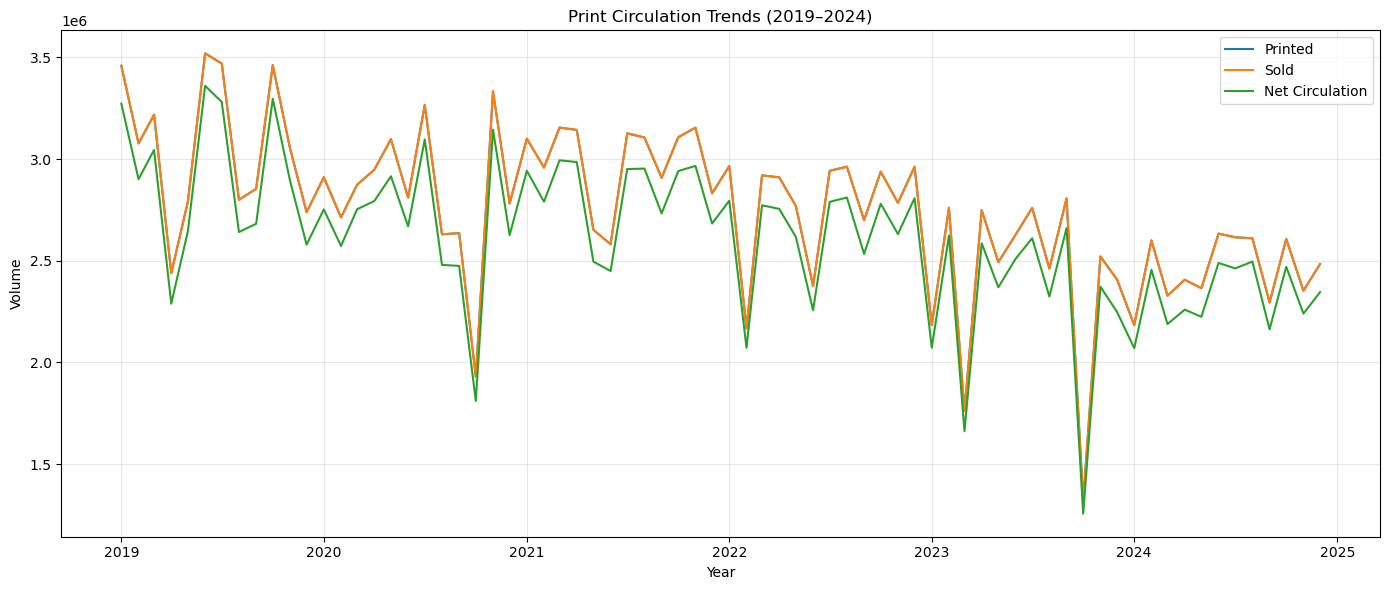

In [18]:
# Step 4: Convert month column to datetime and plot trends
df_circulation['month'] = pd.to_datetime(df_circulation['month'])

plt.figure(figsize=(14, 6))
plt.plot(df_circulation.groupby('month')['total_printed'].sum(), label='Printed')
plt.plot(df_circulation.groupby('month')['total_sold'].sum(), label='Sold')
plt.plot(df_circulation.groupby('month')['total_circulation'].sum(), label='Net Circulation')
plt.title("Print Circulation Trends (2019–2024)")
plt.xlabel("Year")
plt.ylabel("Volume")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
   

##Print Circulation - 
1. 2019 has circulated 3.2M Copies assuming the highest copies sold of all time, which is also the initial year.
2. And continuously thereon we can find the printing as well as circulation drop year on year with heavy crashes.
3. In 2023 we see a major crash to only circulating less than 1.2 M .But the recovery is seen in 2024.

In [25]:
 query_top_cities = """
SELECT
    dc.city,
    SUM(dps.copies_sold) AS total_sold,
    SUM(dps.Net_Circulation) AS total_circulation
FROM fact_print_sales dps
JOIN dim_city dc ON dps.City_ID = dc.City_ID
WHERE YEAR(dps.Month_numeric) = 2024
GROUP BY dc.city
ORDER BY total_circulation DESC, total_sold DESC
LIMIT 10;
"""

 

In [26]:
df_top_cities = pd.read_sql(query_top_cities, conn)

 

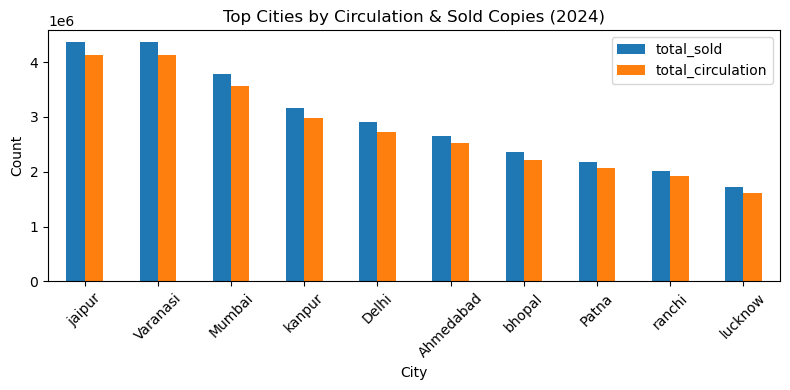

In [27]:
# Plot total sold and circulation per city
df_top_cities.plot(x='city', y=['total_sold', 'total_circulation'], kind='bar', figsize=(8,4))
plt.title("Top Cities by Circulation & Sold Copies (2024)")
plt.xlabel("City")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## top 3 cities i.e Jaipur, Varanasi,Mumbai have circulated nearly from 3.8-4.3 M copies for 2024

#primary analysis 3 waste analysis

In [28]:


query_waste = """
SELECT
    dc.city,
    DATE_FORMAT(dps.Month_numeric, '%Y-%m') AS month,
    SUM(dps.copies_sold) - SUM(dps.Net_Circulation) AS waste
FROM fact_print_sales dps
JOIN dim_city dc ON dps.City_ID = dc.City_ID
WHERE dps.Month_numeric BETWEEN '2019-01-01' AND '2024-12-31'
GROUP BY dc.city, month
ORDER BY waste DESC
"""
 

In [29]:
df_waste = pd.read_sql(query_waste, conn)
df_waste['month'] = pd.to_datetime(df_waste['month'])

 

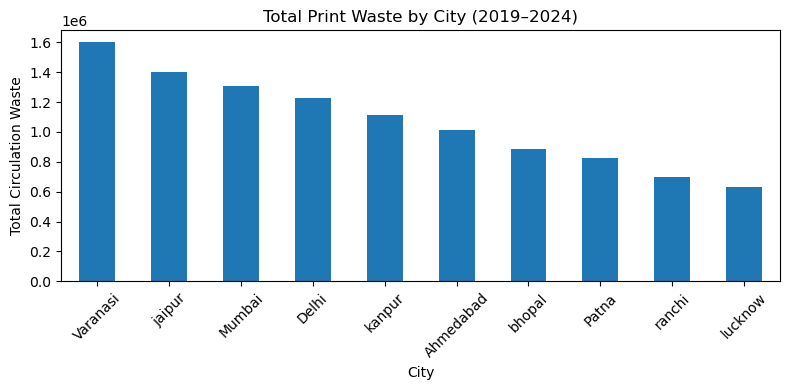

In [30]:
 waste_by_city = df_waste.groupby('city')['waste'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 4))
waste_by_city.plot(kind='bar')
plt.title('Total Print Waste by City (2019–2024)')
plt.xlabel('City')
plt.ylabel('Total Circulation Waste')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# waste analysis -
1. Varanasi and Delhi waste copies more than they circulate copies NEARLY TO 1.2 - 1.6 m 
2. top 3 in waste copies are Varanasi,Jaipur,Mumbai

#ad revenue trends by category

In [50]:
query_ad_revenue = """
 SELECT
    dac.standard_ad_category,
    SUBSTRING(quarter, 1, 4) AS year,
    SUM(ad_revenue) AS total_revenue,
    currency
FROM fact_ad_revenue far
join dim_ad_category dac on dac.ad_categoryid=far.ad_category
WHERE SUBSTRING(quarter, 1, 4) BETWEEN '2019' AND '2024'
GROUP BY dac.standard_ad_category, year, currency
ORDER BY year, dac.standard_ad_category, currency;
"""
 

In [51]:
df_ad_revenue = pd.read_sql(query_ad_revenue, conn)

 

In [55]:
 
 
df_ad_revenue['year'] = df_ad_revenue['year'].astype(int)
df_ad_revenue = df_ad_revenue.sort_values(['standard_ad_category', 'year'])

 
 

In [58]:
 plt.figure(figsize=(12,6))
categories = df_ad_revenue['standard_ad_category'].unique()
years = sorted(df_ad_revenue['year'].unique())

 

<Figure size 1200x600 with 0 Axes>

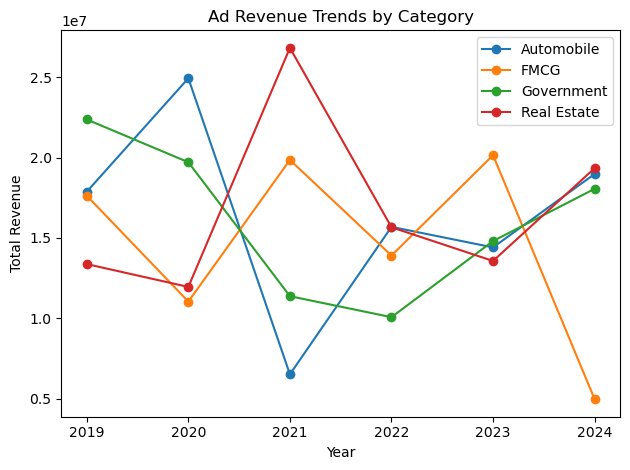

In [59]:
 for category in categories:
    temp = df_ad_revenue[df_ad_revenue['standard_ad_category'] == category]
    # Aggregate yearly revenue for this category
    temp = temp.groupby('year', as_index=False)['total_revenue'].sum()
    # Now reindex to fill gaps (if needed)
    temp = temp.set_index('year').reindex(years, fill_value=0).reset_index()
    plt.plot(temp['year'], temp['total_revenue'], marker='o', label=category)

plt.title("Ad Revenue Trends by Category")
plt.xlabel("Year")
plt.ylabel("Total Revenue")
plt.legend()
plt.tight_layout()
plt.show()

 

## the numbers are in crores i.e 1.0 = 10 M = 1 cr
In 2024 except FMCG which is crashed .All other ad categories remain at 1.7 cr in ad revenue.
govt,real estate and automobiles have stabilized and growing together from 2023


#city level ad revenue performance

In [60]:
query_city_ad = """
SELECT
    dc.city,
    SUM(fas.ad_revenue) AS total_ad_revenue,
    SUM(dps.Net_Circulation) AS total_circulation
FROM fact_ad_revenue fas
JOIN fact_print_sales dps ON fas.edition_id = dps.edition_id
JOIN dim_city dc ON dps.City_ID = dc.City_ID
WHERE SUBSTRING(fas.quarter, 1, 4) BETWEEN '2019' AND '2024'
GROUP BY dc.city
ORDER BY total_ad_revenue DESC
"""
 

In [61]:
df_city_ad = pd.read_sql(query_city_ad, conn)

 

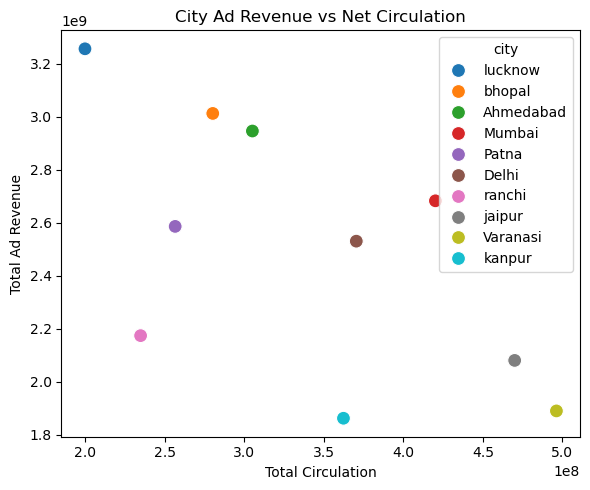

In [62]:
import seaborn as sns
plt.figure(figsize=(6,5))
sns.scatterplot(data=df_city_ad, x='total_circulation', y='total_ad_revenue', hue='city', s=100)
plt.title("City Ad Revenue vs Net Circulation")
plt.xlabel("Total Circulation")
plt.ylabel("Total Ad Revenue")
plt.tight_layout()
plt.show()




## ad revenue vs net circulation
Although we know that Jaipur, Varanasi, and Mumbai top in net circulation, they provide the least ad revenue with respect to the circulation that should be considered.
Whereas Lucknow, Bhopal and Ahmedabad have the highest ad revenue with the least copies circulated.



#digital readiness by city

In [ ]:
query_digital = """
SELECT
    dc.city,
    AVG(fcr.smartphone_penetration) AS avg_smartphone,
    AVG(fcr.internet_penetration) AS avg_internet,
    AVG(fcr.literacy_rate) AS avg_literacy
FROM fact_city_readiness fcr
JOIN dim_city dc ON fcr.city_id = dc.City_ID
WHERE SUBSTRING(fcr.quarter, 1, 4) BETWEEN '2019' AND '2024'
GROUP BY dc.city
ORDER BY avg_smartphone DESC, avg_internet DESC
"""
 

In [ ]:
df_digital = pd.read_sql(query_digital, conn)


In [ ]:
df_digital.set_index('city')[['avg_smartphone','avg_internet','avg_literacy']].plot(kind='bar', figsize=(8,4))
plt.title("Digital Readiness by City")
plt.ylabel("Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Ad Revenue per Net Circulation by City and Year


In [ ]:
 
query_roi = """
SELECT
    dc.city,
    SUBSTRING(fas.quarter, 1, 4) AS year,
    SUM(fas.ad_revenue) AS total_ad_revenue,
    SUM(dps.Net_Circulation) AS total_circulation,
    ROUND(SUM(fas.ad_revenue) / SUM(dps.Net_Circulation), 2) AS revenue_per_copy
FROM fact_ad_revenue fas
JOIN fact_print_sales dps ON fas.edition_id = dps.edition_id
JOIN dim_city dc ON dps.City_ID = dc.City_ID
WHERE SUBSTRING(fas.quarter, 1, 4) BETWEEN '2019' AND '2024'
AND dps.Net_Circulation > 0
GROUP BY dc.city, year
HAVING total_circulation > 0
ORDER BY revenue_per_copy DESC
"""
 

In [ ]:
df_roi = pd.read_sql(query_roi, conn)

 

In [ ]:
# Top cities by ROI (overall)
top_roi_cities = df_roi.groupby('city')['revenue_per_copy'].mean().nlargest(10)
plt.figure(figsize=(8, 4))
top_roi_cities.plot(kind='bar')
plt.title('Top Cities by Average Ad Revenue per Net Circulated Copy')
plt.xlabel('City')
plt.ylabel('Revenue per Copy')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

 

In [ ]:
# ROI trend over time for top 5 cities
plt.figure(figsize=(8, 4))
for city in top_roi_cities.head(5).index:
    city_data = df_roi[df_roi['city'] == city]
    plt.plot(city_data['year'], city_data['revenue_per_copy'], marker='o', label=city)
plt.title('Ad Revenue per Copy Trend Over Time (Top 5 Cities)')
plt.xlabel('Year')
plt.ylabel('Revenue per Copy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


#digital relaunch

In [10]:
 query_prioritization = """
 SELECT
    dc.city,
    AVG(fcr.smartphone_penetration) AS avg_smartphone,
    AVG(fcr.internet_penetration) AS avg_internet,
    AVG(fcr.literacy_rate) AS avg_literacy,
    d2019.circulation_2019,
    d2024.circulation_2024
FROM dim_city dc
JOIN fact_city_readiness fcr ON fcr.city_id = dc.City_ID
LEFT JOIN (
    SELECT City_ID, SUM(Net_Circulation) AS circulation_2019
    FROM fact_print_sales
    WHERE YEAR(Month_numeric) = 2019
    GROUP BY City_ID
) d2019 ON d2019.City_ID = dc.City_ID
LEFT JOIN (
    SELECT City_ID, SUM(Net_Circulation) AS circulation_2024
    FROM fact_print_sales
    WHERE YEAR(Month_numeric) = 2024
    GROUP BY City_ID
) d2024 ON d2024.City_ID = dc.City_ID
WHERE SUBSTRING(fcr.quarter, 1, 4) BETWEEN '2019' AND '2024'
GROUP BY dc.city, dc.City_ID, d2019.circulation_2019, d2024.circulation_2024
HAVING circulation_2019 > 0 AND circulation_2024 > 0;
"""
 

In [17]:
df_priority = pd.read_sql(query_prioritization, conn)

 

In [18]:
# Calculate print decline rate and digital readiness score
df_priority['print_decline'] = ((df_priority['circulation_2019'] - df_priority['circulation_2024']) / df_priority['circulation_2019']) * 100
df_priority['digital_score'] = (df_priority['avg_smartphone'] + df_priority['avg_internet'] + df_priority['avg_literacy']) / 3


In [19]:
# Prioritization score (higher digital readiness + higher print decline = higher priority)
df_priority['priority_score'] = df_priority['digital_score'] + (df_priority['print_decline'] * 0.5)
df_priority = df_priority.sort_values('priority_score', ascending=False)



In [20]:
# Top 3 cities for digital relaunch
top_3_cities = df_priority.head(3)
print("Top 3 Cities for Digital Relaunch Priority:")
print(top_3_cities[['city', 'digital_score', 'print_decline', 'priority_score']])


Top 3 Cities for Digital Relaunch Priority:
        city  digital_score  print_decline  priority_score
2     bhopal      73.287778      25.853251       86.214403
0    lucknow      73.494444      24.437078       85.712983
8  Ahmedabad      72.735000      24.266658       84.868329


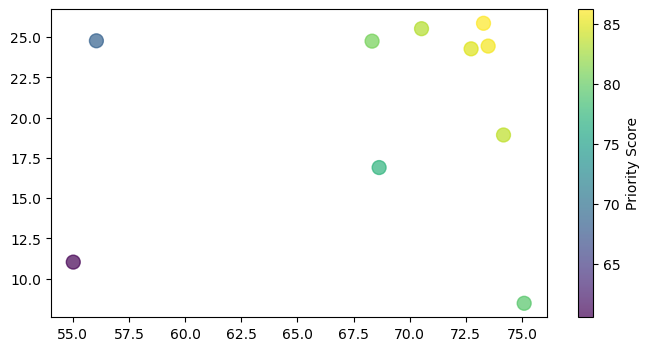

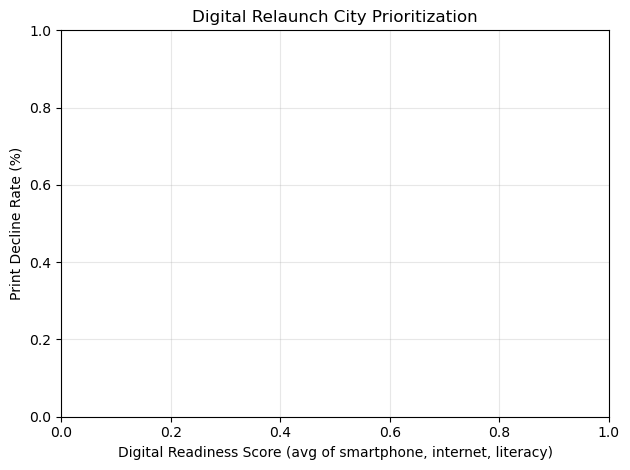

In [22]:
# Highlight top 3 cities
for i, row in top_3_cities.iterrows():
    plt.annotate(row['city'], (row['digital_score'], row['print_decline']), 
                xytext=(3, 3), textcoords='offset points', fontsize=10, 
                bbox=dict(boxstyle='round,pad=0.2', facecolor='yellow', alpha=0.4))

plt.title('Digital Relaunch City Prioritization')
plt.xlabel('Digital Readiness Score (avg of smartphone, internet, literacy)')
plt.ylabel('Print Decline Rate (%)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


 

<Figure size 800x400 with 0 Axes>

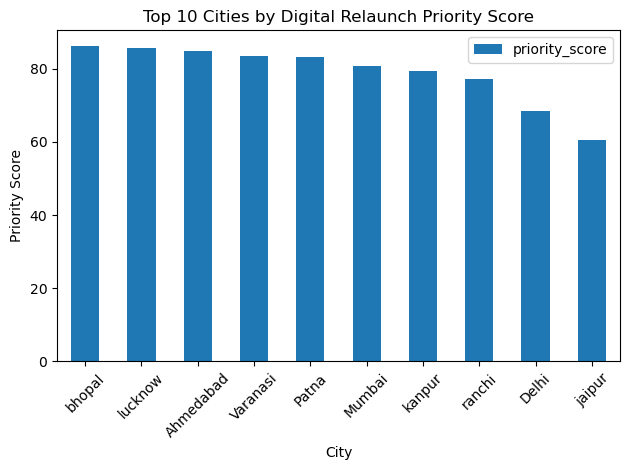

In [23]:
# Bar chart of top 10 priority cities
plt.figure(figsize=(8, 4))
df_priority.head(10).plot(x='city', y='priority_score', kind='bar')
plt.title('Top 10 Cities by Digital Relaunch Priority Score')
plt.xlabel('City')
plt.ylabel('Priority Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
 